## EDA
- Data Overview (shape, dtypes, cardinalidad)
- Missings
- Features Numéricas
- Features Categóricas
- Análisis del Target
- Split resumen: Train/Test/OOT
- Análisis de Correlación Pearson, Spearman, Mutual Information & VIF

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import missingno
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
from pathlib import Path
import sys
import os
import mlflow
import dagshub

PARENT_DIRECTORY = Path.cwd().parent
#print(Path.cwd())
#print(PARENT_DIRECTORY)
sys.path.append(str(PARENT_DIRECTORY))
# sys.path.append(f'{PARENT_DIRECTORY}/scripts')
#print(sys.path)

from scripts.eda import EDA

sns.set_theme(style= 'whitegrid', context= 'notebook', palette= 'deep')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

### Data Overview

In [17]:
with open('../params.yaml', 'r') as f:
    params = yaml.safe_load(f)

In [18]:
df = pd.read_csv(params['config']['data_raw'], 
            parse_dates= ['period'])
df = df.sort_values(by= ['customer_id', 'period'], ascending= [True, True])
df.head()

,customer_id,period,tenure_months,age,monthly_charges,usage_minutes,support_calls,complaints_last_3m,late_payments,marketing_emails_opened,active_days_last_month,region,contract_type,payment_method,churn
0,C0000001,2023-01-01,1,42,59.63,345.1,1,0,0,8,14,Lima,Monthly,Debit,0
10000,C0000001,2023-02-01,2,42,54.73,289.4,2,0,0,2,22,Lima,Monthly,Debit,0
20000,C0000001,2023-03-01,3,42,61.51,230.0,0,0,1,7,23,Lima,Monthly,Debit,0
30000,C0000001,2023-04-01,4,42,53.77,225.9,1,1,0,3,25,Lima,Monthly,Debit,0
40000,C0000001,2023-05-01,5,42,57.69,337.8,2,0,0,1,19,Lima,Monthly,Debit,0


In [19]:
df.dtypes

customer_id                           str
period                     datetime64[us]
tenure_months                       int64
age                                 int64
monthly_charges                   float64
usage_minutes                     float64
support_calls                       int64
complaints_last_3m                  int64
late_payments                       int64
marketing_emails_opened             int64
active_days_last_month              int64
region                                str
contract_type                         str
payment_method                        str
churn                               int64
dtype: object

In [20]:
# Cardinalidad

unicos = [len(df[d].unique()) for d in df.columns]

cardinalidad_df = pd.DataFrame({
    'feature': df.columns,
    'tipo': df.dtypes.values.astype(str),
    'cardinalidad': unicos
}).sort_values(by= ['tipo', 'cardinalidad'], ascending= False)

cardinalidad_df.to_csv(
    '../artifacts/eda/tables/tabla_cardinalidad_dtypes.csv',
    index= False
)


In [21]:
eda_data_overview = f'''=== Reporte de Data Overview ===

Forma del dataset                          : {df.shape[0]} filas | {df.shape[1]} columnas
Target                                     : "churn" -> Binaria (0, 1)
Cantidad de Features Numéricas             : 9
Cantidad de Features Categóricas           : 3
Feature del tiempo                         : "period"
Features Categóricas con alta cardinalidad : Ninguna
Features Categóricas con baja cardinalidad : "region", "payment_method", "contract_type"
'''
print(eda_data_overview)

=== Reporte de Data Overview ===

Forma del dataset                          : 480000 filas | 15 columnas
Target                                     : "churn" -> Binaria (0, 1)
Cantidad de Features Numéricas             : 9
Cantidad de Features Categóricas           : 3
Feature del tiempo                         : "period"
Features Categóricas con alta cardinalidad : Ninguna
Features Categóricas con baja cardinalidad : "region", "payment_method", "contract_type"



In [22]:
# Missings

missings_count_col = [df[d].isna().sum() for d in df.columns]
missings_mean_col = [df[d].isna().mean() for d in df.columns]

missings_df = pd.DataFrame({
    'feature': df.columns,
    'Cantidad de Missings': missings_count_col,
    '% de Missings': missings_mean_col
})

missings_df.to_csv(
    '../artifacts/eda/tables/tabla_missings.csv',
    index= False
)

/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))
/opt/miniconda3/envs/ciencia-de-datos/lib/python3.11/site-packages/seaborn/matrix.py:309: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  ax.set(xlim=(0, self.data.shape[1]), ylim=(0, self.data.shape[0]))


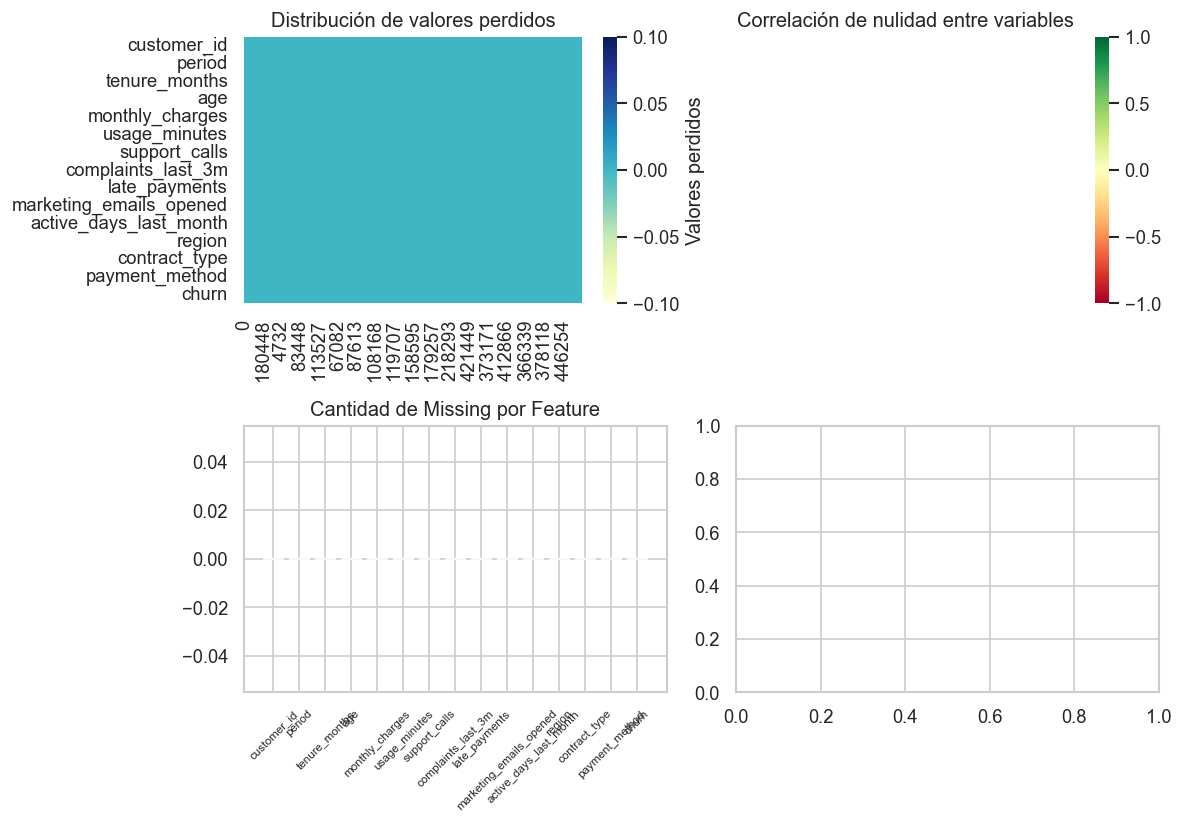

In [23]:
# Missings

fig, ax = plt.subplots(2, 2, figsize = (10, 7))
axes = ax.flatten()

sns.heatmap(
    data= df.isnull().transpose(),
    cmap= 'YlGnBu',
    cbar_kws = {'label': 'Valores perdidos'},
    ax= axes[0]
)
axes[0].set_title('Distribución de valores perdidos')

missingno.heatmap(
    df= df,
    cmap= 'RdYlGn',
    figsize= (10,5),
    fontsize= 12,
    ax = axes[1]
)
axes[1].set_title('Correlación de nulidad entre variables')

axes[2].bar(
    missings_df['feature'],
    missings_df['Cantidad de Missings'],
)
axes[2].tick_params(axis = 'x', rotation = 45, labelsize = 7)
axes[2].set_title('Cantidad de Missing por Feature')
plt.tight_layout()

fig.savefig(
    '../artifacts/eda/figures/analisis_missings.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)

plt.show()

In [24]:
eda_reporte_missing = f'''=== Reporte de Missings ===

El dataset NO presenta ningún missing.
Se evaluó lo siguiente:
- Distribución de valores perdidos        : Sin resultados
- Correlación de nulidad entre variables  : Sin resultados 
- Cantidad de missing por feature         : Sin resultados
'''
print(eda_reporte_missing)

=== Reporte de Missings ===

El dataset NO presenta ningún missing.
Se evaluó lo siguiente:
- Distribución de valores perdidos        : Sin resultados
- Correlación de nulidad entre variables  : Sin resultados 
- Cantidad de missing por feature         : Sin resultados



### Features Numéricas

In [25]:
FEATS_NUMERICAS = [
    'tenure_months',
    'age',
    'active_days_last_month',
    'marketing_emails_opened',
    'support_calls',
    'complaints_last_3m',
    'late_payments',
    'usage_minutes',
    'monthly_charges'
]
FEATS_CATEGORICAS = [
    'region',
    'payment_method',
    'contract_type'
]
TARGET = 'churn'
PERIODO = 'period'

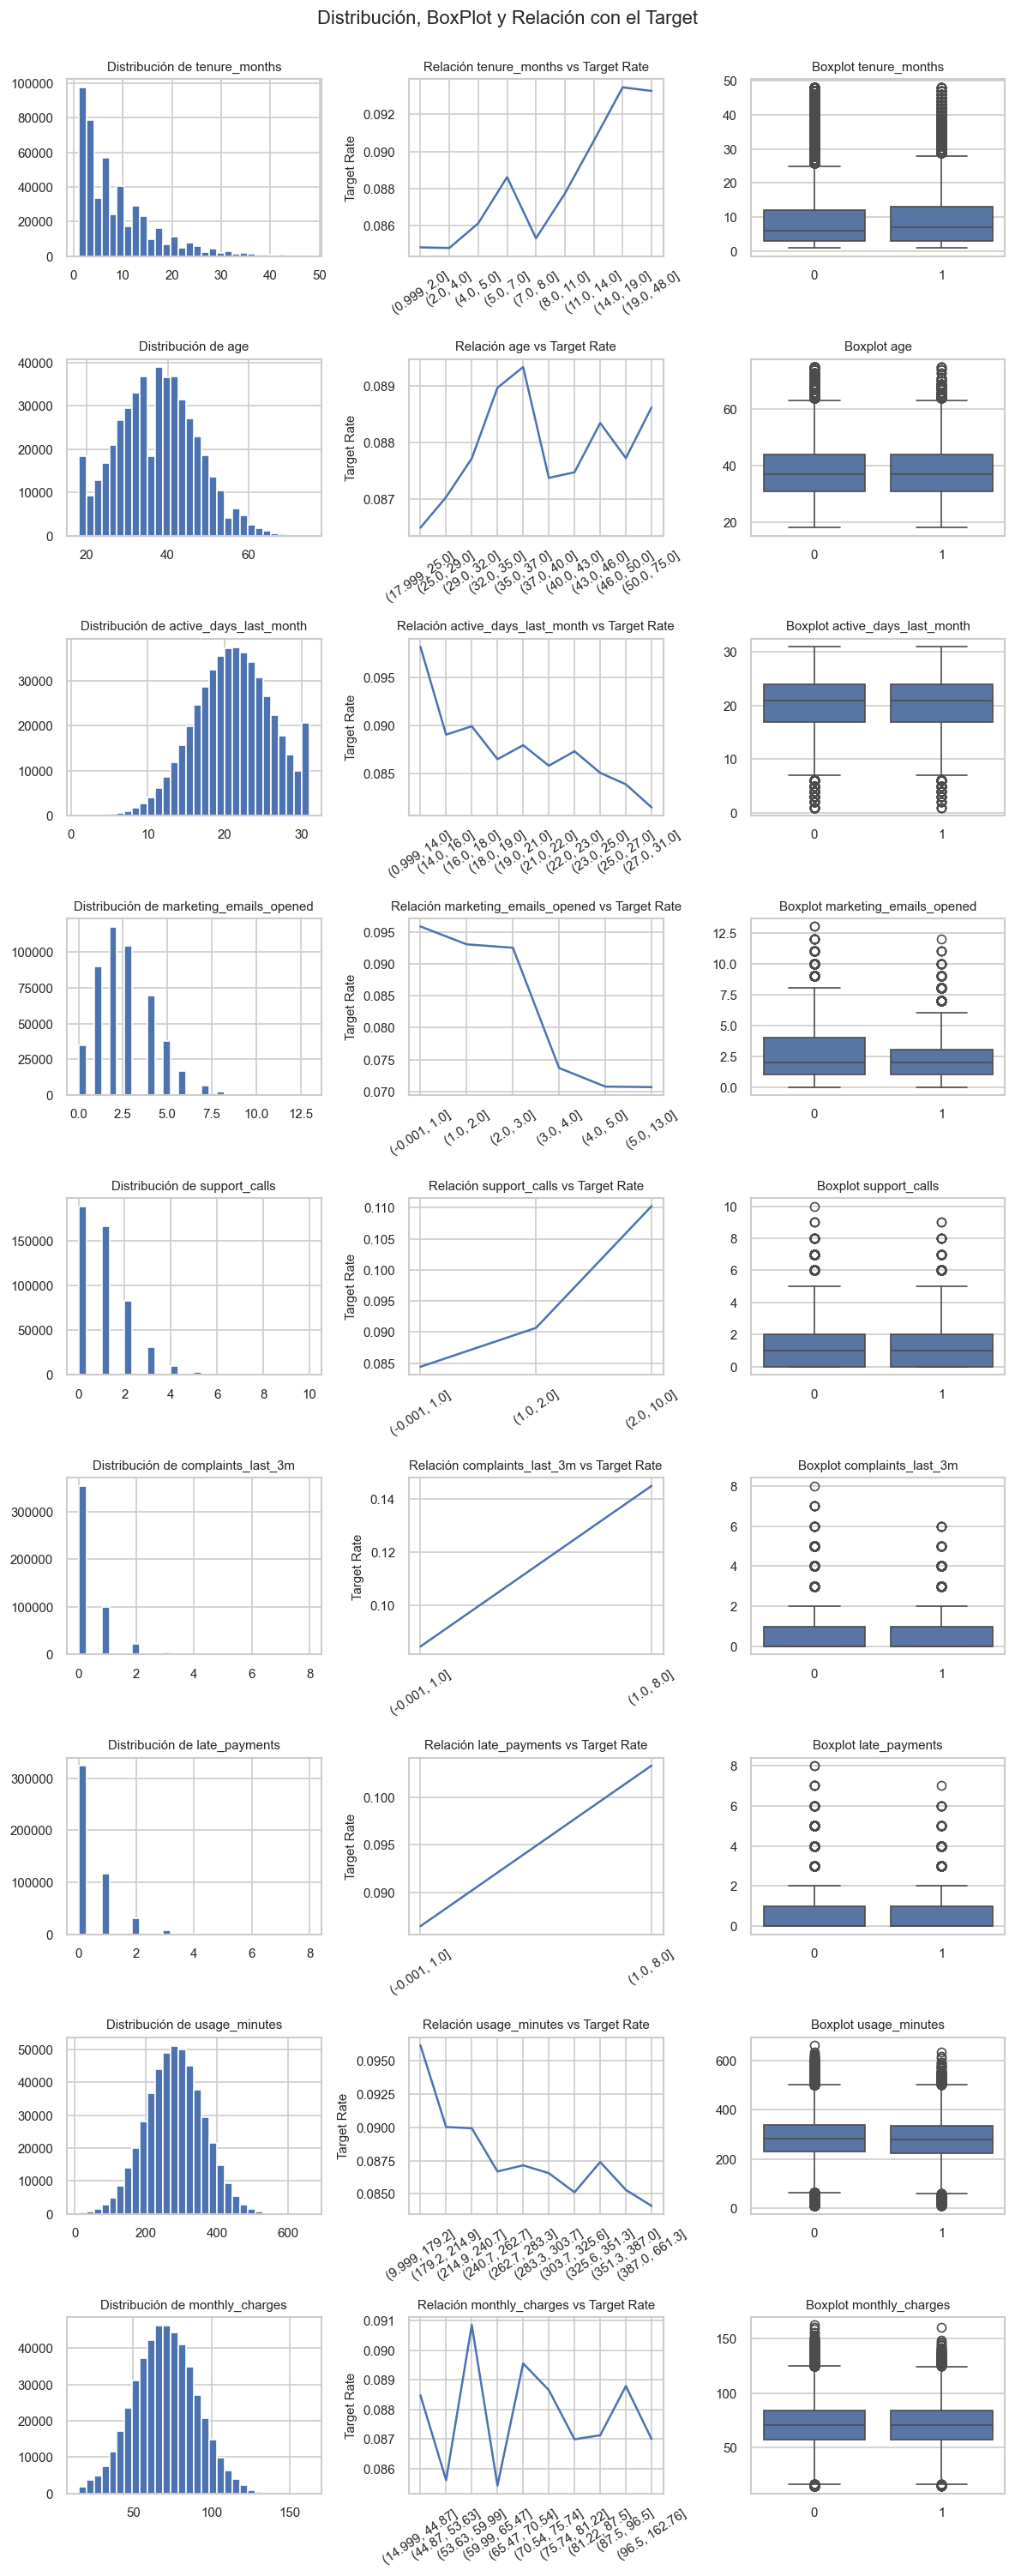

In [44]:
## Distribución y BoxPlot

fig, ax = plt.subplots(9, 3, figsize = (10, 25))
#axes = ax.flatten()

for i, var in enumerate(FEATS_NUMERICAS):
    ax[i,0].hist(
        df[var],
        bins = 30
        #color='tab:blue'
    )
    ax[i, 0].set_title(f'Distribución de {var}', fontsize = 9)
    ax[i, 0].tick_params(axis= 'x', labelsize = 9)
    ax[i, 0].tick_params(axis = 'y', labelsize = 9)

    sns.boxplot(
        data = df,
        x = TARGET,
        y = var,
        ax= ax[i,2]
        #orient = 'v'
        
    )
    ax[i,2].set_title(f'Boxplot {var}', fontsize = 9)
    ax[i,2].tick_params(axis='x', labelsize = 9)
    ax[i,2].tick_params(axis='y', labelsize = 9)
    ax[i,2].set_xlabel("")
    ax[i,2].set_ylabel("")

    df_tmp = df.copy()
    df_tmp['bin'] = pd.qcut(
        x= df[var],
        q= 10,
        duplicates= 'drop'
    )
    agg = df_tmp.groupby(
        ['bin']
    ).agg(
        event_rate = (TARGET, 'mean')
    ).reset_index(level= 0, drop= False)
    agg['bin'] = agg['bin'].astype(str)
    
    sns.lineplot(
        data= agg,
        ax= ax[i,1],
        x= 'bin',
        y= 'event_rate',
        markers= 'o',
        
    )
    ax[i,1].set_title(f'Relación {var} vs Target Rate', fontsize = 9)
    ax[i,1].tick_params(axis = 'x', labelsize = 9, labelrotation= 34)
    ax[i,1].tick_params(axis = 'y', labelsize = 9)
    ax[i,1].set_xlabel("")
    ax[i,1].set_ylabel("Target Rate", fontsize = 9)
    
    
    # agg = df.groupby(
    #     TARGET
    # ).agg(
    #     mean = (var, 'mean')
    # ).reset_index(level= 0, drop= False)
    
    # bar = ax[i,2].bar(
    #     agg['churn'],
    #     round(agg['mean'],2)
    # )
    # ax[i,2].bar_label(bar, fontsize = 9)
    # ax[i,2].tick_params(axis = 'x', labelsize = 9)
    # ax[i,2].tick_params(axis = 'y', labelsize = 9)
    # ax[i,2].set_title(f'{var} vs Promedio Churn', fontsize = 9)

    
plt.suptitle('Distribución, BoxPlot y Relación con el Target', y= 1.0001)
plt.tight_layout()

fig.savefig(
    '../artifacts/eda/figures/analisis_feats_numericas.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)


In [27]:
eda_analisis_feats_numericas = f'''=== Reporte de Features Numéricas ===

Se puede observar lo siguiente:
- Existe relación monotónica creciente en las siguientes features: 
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Las siguientes features tienen una cola hacia la derecha:
      - "marketing_emails_opened"
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Pero al ser estas últimas variables discretas (conteos) y de baja cardinalidad,
no será necesaria ninguna transformación.
'''
print(eda_analisis_feats_numericas)

=== Reporte de Features Numéricas ===

Se puede observar lo siguiente:
- Existe relación monotónica creciente en las siguientes features: 
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Las siguientes features tienen una cola hacia la derecha:
      - "marketing_emails_opened"
      - "support_calls"
      - "complaints_last_3m"
      - "late_payments"
- Pero al ser estas últimas variables discretas (conteos) y de baja cardinalidad,
no será necesaria ninguna transformación.



### Features Categóricas

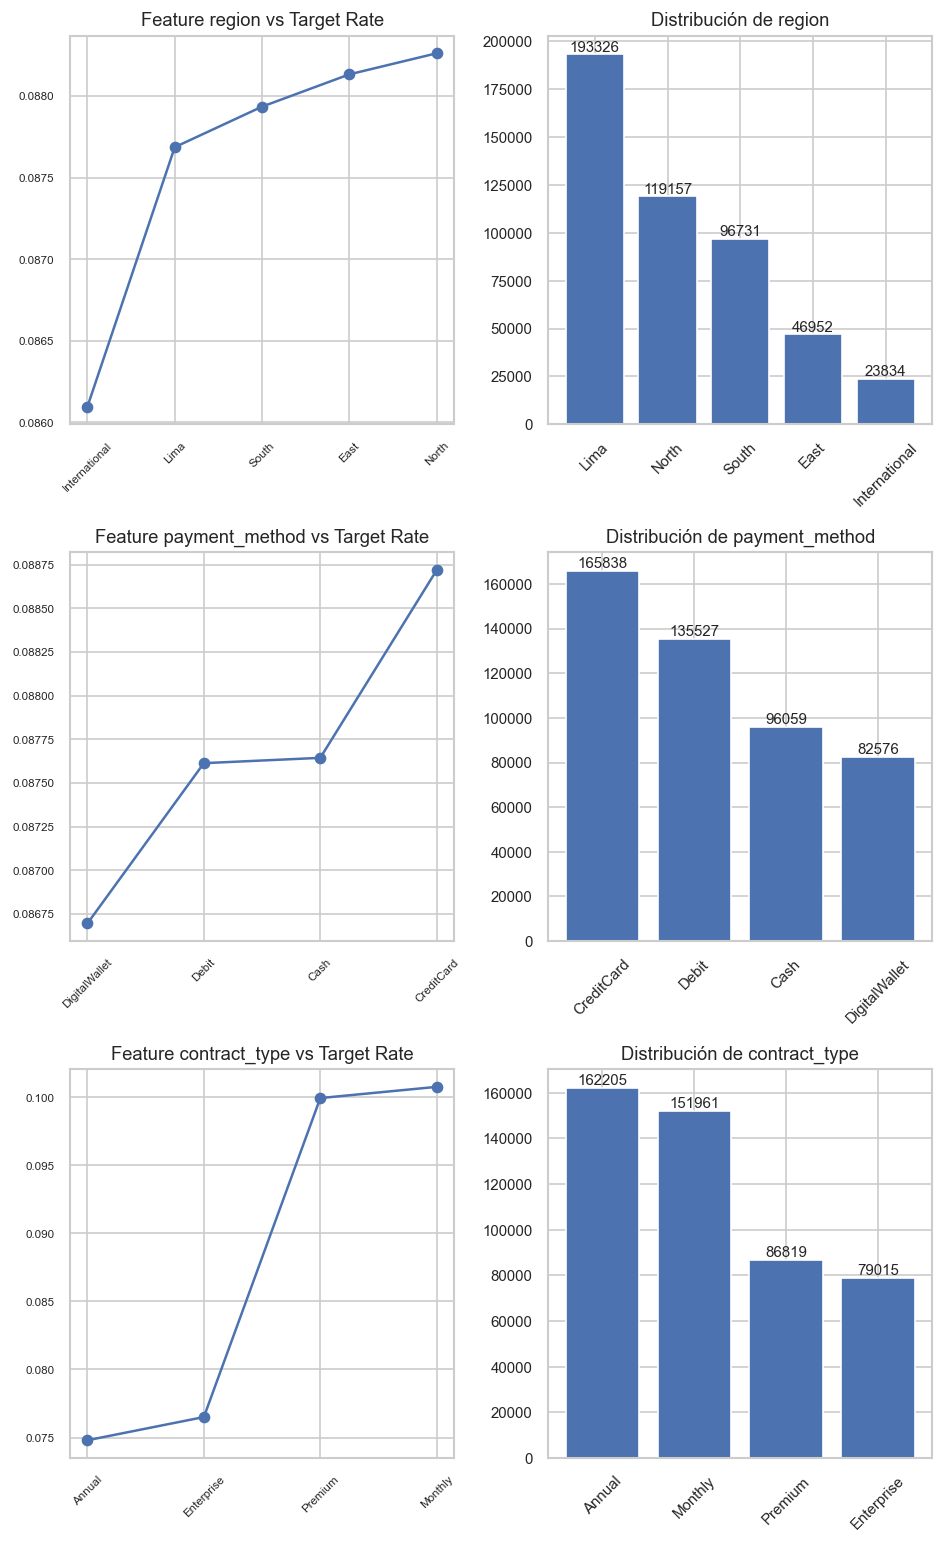

In [28]:
fig, ax = plt.subplots(3, 2, figsize = (8, 13))
for i, var in enumerate(FEATS_CATEGORICAS):
    agg = df.groupby(
        [var]
    ).agg(
        mean_target = (TARGET, 'mean'),
        count_var = (var, 'count')
    ).reset_index(level=0, drop= False).sort_values(by= 'mean_target', ascending= True)
    
    ax[i,0].plot(
        agg[var],
        agg['mean_target'],
        marker = 'o'
    )
    ax[i,0].tick_params(axis = 'x', labelsize = 7, rotation = 45)
    ax[i,0].tick_params(axis = 'y', labelsize = 7)
    ax[i,0].set_title(f'Feature {var} vs Target Rate', fontsize = 11)

    agg = agg.sort_values(by= 'count_var', ascending = False)
    bar = ax[i,1].bar(
        agg[var],
        agg['count_var'],
    )
    ax[i,1].bar_label(bar, fontsize = 9)
    ax[i,1].set_title(f'Distribución de {var}', fontsize = 11)
    ax[i,1].tick_params(axis = 'x', labelsize = 9, rotation = 45)
    ax[i,1].tick_params(axis = 'y', labelsize = 9)
plt.tight_layout()

fig.savefig(
    '../artifacts/eda/figures/analisis_categoricas.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)

plt.show()

In [29]:
eda_analisis_feats_categoricas = f'''=== Reporte de Features Categóricas ===

Se identificó que aunque existe ligeros aumentos del churn rate promedio 
entre las categorías del mismo feature, no es un aumento considerable y tampoco
existe una relación ordinal clara para separarlo ordinalmente.

Además, la distribución de cada feature categórica muestra que no existen etiquetas 
o niveles raros a considerar. 
      
Posible features con OHE:
      - region
      - payment_method
      - contract_type
'''
print(eda_analisis_feats_categoricas)

=== Reporte de Features Categóricas ===

Se identificó que aunque existe ligeros aumentos del churn rate promedio 
entre las categorías del mismo feature, no es un aumento considerable y tampoco
existe una relación ordinal clara para separarlo ordinalmente.

Además, la distribución de cada feature categórica muestra que no existen etiquetas 
o niveles raros a considerar. 

Posible features con OHE:
      - region
      - payment_method
      - contract_type



### Análisis del Target

In [30]:
## Registros por período
agg_period = df.groupby(
    ['period']
).agg(
    n_registros = (TARGET, 'count'),
    n_event = (TARGET, 'sum'),
    target_mean = (TARGET, 'mean')
).reset_index(level= 0, drop = False)
agg_period['n_no_event'] = agg_period['n_registros'] - agg_period['n_event']

agg_period_2023_2024 = agg_period.loc[agg_period['period'] < '2025-01-01']
agg_period_2025 = agg_period.loc[(agg_period['period'] > '2024-12-01') & (agg_period['period'] < '2026-01-01')]
agg_period_2026 = agg_period.loc[(agg_period['period'] > '2025-12-01') & (agg_period['period'] < '2027-01-01')]

share_registros_2023_2024 = agg_period_2023_2024['n_registros'].sum() / agg_period['n_registros'].sum()
share_registros_2025 = agg_period_2025['n_registros'].sum() / agg_period['n_registros'].sum()
share_registros_2026 = agg_period_2026['n_registros'].sum() / agg_period['n_registros'].sum()

media_2023_2024 = df.loc[df['period'] < '2025-01-01'][TARGET].mean()
media_2025 = df.loc[(df['period'] > '2024-12-01') & (df['period'] < '2026-01-01')][TARGET].mean()
media_2026 = df.loc[(df['period'] > '2025-12-01') & (df['period'] < '2027-01-01')][TARGET].mean()

## Métricas auxiliares para tercer gráfico
event_rate_2023_2024 = agg_period_2023_2024['n_event'].sum() / agg_period_2023_2024['n_registros'].sum()
no_event_rate_2023_2024 = agg_period_2023_2024['n_no_event'].sum() / agg_period_2023_2024['n_registros'].sum()

event_rate_2025 = agg_period_2025['n_event'].sum() / agg_period_2025['n_registros'].sum()
no_event_rate_2025 = agg_period_2025['n_no_event'].sum() / agg_period_2025['n_registros'].sum()

event_rate_2026 = agg_period_2026['n_event'].sum() / agg_period_2026['n_registros'].sum()
no_event_rate_2026 = agg_period_2026['n_no_event'].sum() / agg_period_2026['n_registros'].sum()


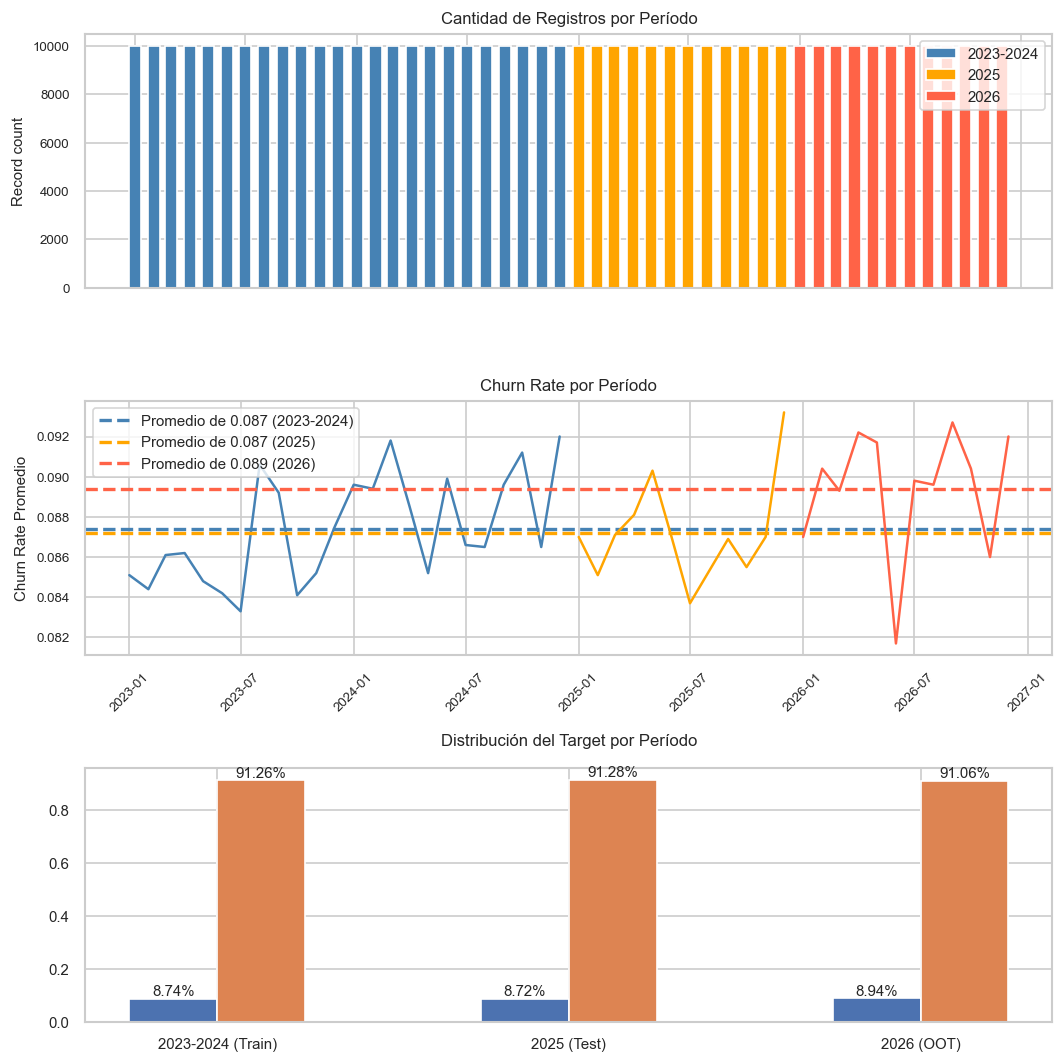

In [31]:
fig, ax = plt.subplots(3, 1, figsize = (9, 9))
ax[0].bar(
    agg_period_2023_2024['period'],
    agg_period_2023_2024['n_registros'],
    color = 'steelblue',
    width= 20,
    label = '2023-2024'
)

ax[0].bar(
    agg_period_2025['period'],
    agg_period_2025['n_registros'],
    width = 20,
    color = 'orange',
    label = '2025'
)

ax[0].bar(
    agg_period_2026['period'],
    agg_period_2026['n_registros'],
    width = 20,
    color = 'tomato',
    label = '2026'
)
ax[0].set_ylabel('Record count', fontsize = 9)
ax[0].tick_params(axis = 'y', labelsize = 8)
ax[0].tick_params(axis = 'x', labelbottom = False)
ax[0].set_title(f'Cantidad de Registros por Período', fontsize = 10)
ax[0].legend(fontsize = 9)

## Gráfico 2
ax[1].plot(
    agg_period_2023_2024['period'],
    agg_period_2023_2024['target_mean'],
    color = 'steelblue',
    #marker = 'o'
)
ax[1].axhline(
    y = media_2023_2024,
    color = 'steelblue',
    linestyle = '--',
    linewidth= 2,
    label = f'Promedio de {round(media_2023_2024,3)} (2023-2024)'
)

ax[1].plot(
    agg_period_2025['period'],
    agg_period_2025['target_mean'],
    color = 'orange',
    #marker = 'o'
)

ax[1].axhline(
    y = media_2025,
    color = 'orange',
    linestyle = '--',
    linewidth = 2,
    label = f'Promedio de {round(media_2025, 3)} (2025)'
)

ax[1].plot(
    agg_period_2026['period'],
    agg_period_2026['target_mean'],
    color = 'tomato'
)

ax[1].axhline(
    y = media_2026,
    color = 'tomato',
    linestyle = '--',
    linewidth = 2,
    label = f'Promedio de {round(media_2026, 3)} (2026)'
)

ax[1].set_title('Churn Rate por Período', fontsize = 10)
ax[1].set_ylabel('Churn Rate Promedio', fontsize = 9)
ax[1].tick_params(axis = 'x', labelsize = 8, rotation = 45)
ax[1].tick_params(axis = 'y', labelsize = 8)
ax[1].legend(fontsize = 9)

## Gráfico 3
 
categorias = ['2023-2024 (Train)', '2025 (Test)', '2026 (OOT)']
x = np.arange(len(categorias))
width = 0.25

serie_event_rate = [event_rate_2023_2024, event_rate_2025, event_rate_2026]
serie_no_event_rate = [no_event_rate_2023_2024, no_event_rate_2025, no_event_rate_2026]

bar_1 = ax[2].bar(
    x - width/2,
    serie_event_rate,
    width,
    label = 'Event Rate'
)

bar_2 = ax[2].bar(
    x + width/2,
    serie_no_event_rate,
    width,
    label = 'No Event Rate'
)
ax[2].bar_label(bar_1, labels = [f'{d:.2%}' for d in serie_event_rate], fontsize = 9)
ax[2].bar_label(bar_2, labels = [f'{d:.2%}' for d in serie_no_event_rate], fontsize = 9)

ax[2].set_xticks(x)
ax[2].set_xticklabels(categorias)
ax[2].set_title('Distribución del Target por Período', fontsize = 10, y = 1.05)
ax[2].tick_params(axis = 'x', labelsize = 9)
ax[2].tick_params(axis = 'y', labelsize = 9)

plt.tight_layout()

fig.savefig(
    '../artifacts/eda/figures/analisis_target.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)

plt.show()

In [32]:
eda_analisis_target  = f'''=== Reporte de Registros por Período y Churn por Período ===
      
Se observa que la cantidad de registros por período es mayor en los primeros meses 
y tiene una tendencia decreciente hasta el final del mismo.
    - Registros en Train   : {share_registros_2023_2024:.2%}
    - Registros en Test    : {share_registros_2025:.2%}
    - Registros en OOT     : {share_registros_2026:.2%}

Respecto al Churn Rate por período, se observa que tanto el período de Train y Test
son muy similares en comportamiento con igual promedio global de ambos.
Por otro lado, el período propuesto como OOT (2026) sí varía ligeramente el promedio
global y tiene meses con un pico alto de Churn Rate y otros dos bastante bajos.
Se considerará esto al momento de analizar el monitoring y drift.

Por último, respecto a la distribución del Churn por período, se observa un cambio
en la prevalencia del OOT (-0.6pp vs Test | -0.53pp vs Train), al ser un cambio ligero,
se monitoreará principalmente en Calibration Drift.
'''
print(eda_analisis_target)

=== Reporte de Registros por Período y Churn por Período ===

Se observa que la cantidad de registros por período es mayor en los primeros meses 
y tiene una tendencia decreciente hasta el final del mismo.
    - Registros en Train   : 50.00%
    - Registros en Test    : 25.00%
    - Registros en OOT     : 25.00%

Respecto al Churn Rate por período, se observa que tanto el período de Train y Test
son muy similares en comportamiento con igual promedio global de ambos.
Por otro lado, el período propuesto como OOT (2026) sí varía ligeramente el promedio
global y tiene meses con un pico alto de Churn Rate y otros dos bastante bajos.
Se considerará esto al momento de analizar el monitoring y drift.

Por último, respecto a la distribución del Churn por período, se observa un cambio
en la prevalencia del OOT (-0.6pp vs Test | -0.53pp vs Train), al ser un cambio ligero,
se monitoreará principalmente en Calibration Drift.



### Split Resumen

In [33]:
# Split | Período | Rows | Churn Rate

split_resumen = pd.DataFrame({
    'Split': ['Train', 'Test', 'OOT'],
    'Período': ['2023-2024', '2025', '2026'],
    'Rows': [agg_period_2023_2024['n_registros'].sum(), agg_period_2025['n_registros'].sum(), agg_period_2026['n_registros'].sum()],
    'Churn Rate': [event_rate_2023_2024, event_rate_2025, event_rate_2026]
})
split_resumen.to_csv(
    '../artifacts/eda/tables/split_resumen.csv',
    index= False
)


### Análisis de Correlación Pearson, Spearman, VIF (+IV)

In [34]:
## Entrenamiento del Mutual Information
mi_scores = mutual_info_classif(
    X= df[FEATS_NUMERICAS],
    y= df[TARGET],
    discrete_features= 'auto',
    n_neighbors= 3,
    random_state= 42
)
mi_df = pd.DataFrame({
    'feature': df[FEATS_NUMERICAS].columns,
    'mutual_info': mi_scores
}).sort_values(by= 'mutual_info', ascending = False).reset_index(level=0, drop= False)

## Entrenamiento del VIF
vif_df = pd.DataFrame({
    'feature': df[FEATS_NUMERICAS].columns,
    'VIF': [
        variance_inflation_factor(df[FEATS_NUMERICAS].values, i)
        for i in range(df[FEATS_NUMERICAS].shape[1])
    ]
}).sort_values(by= 'VIF', ascending = False)

mi_df[['feature', 'mutual_info']].to_csv(
    '../artifacts/eda/tables/table_mutual_information.csv'
)
vif_df.to_csv(
    '../artifacts/eda/tables/table_vif.csv',
    index= False
)


In [35]:
## Information Value
iv, bins_qcut = EDA().information_value(
    dataframe= df,
    features= FEATS_NUMERICAS,
    target_serie= df[TARGET],
    target_name= TARGET
)
iv.to_csv(
    '../artifacts/eda/tables/table_information_value.csv',
    index= False
)


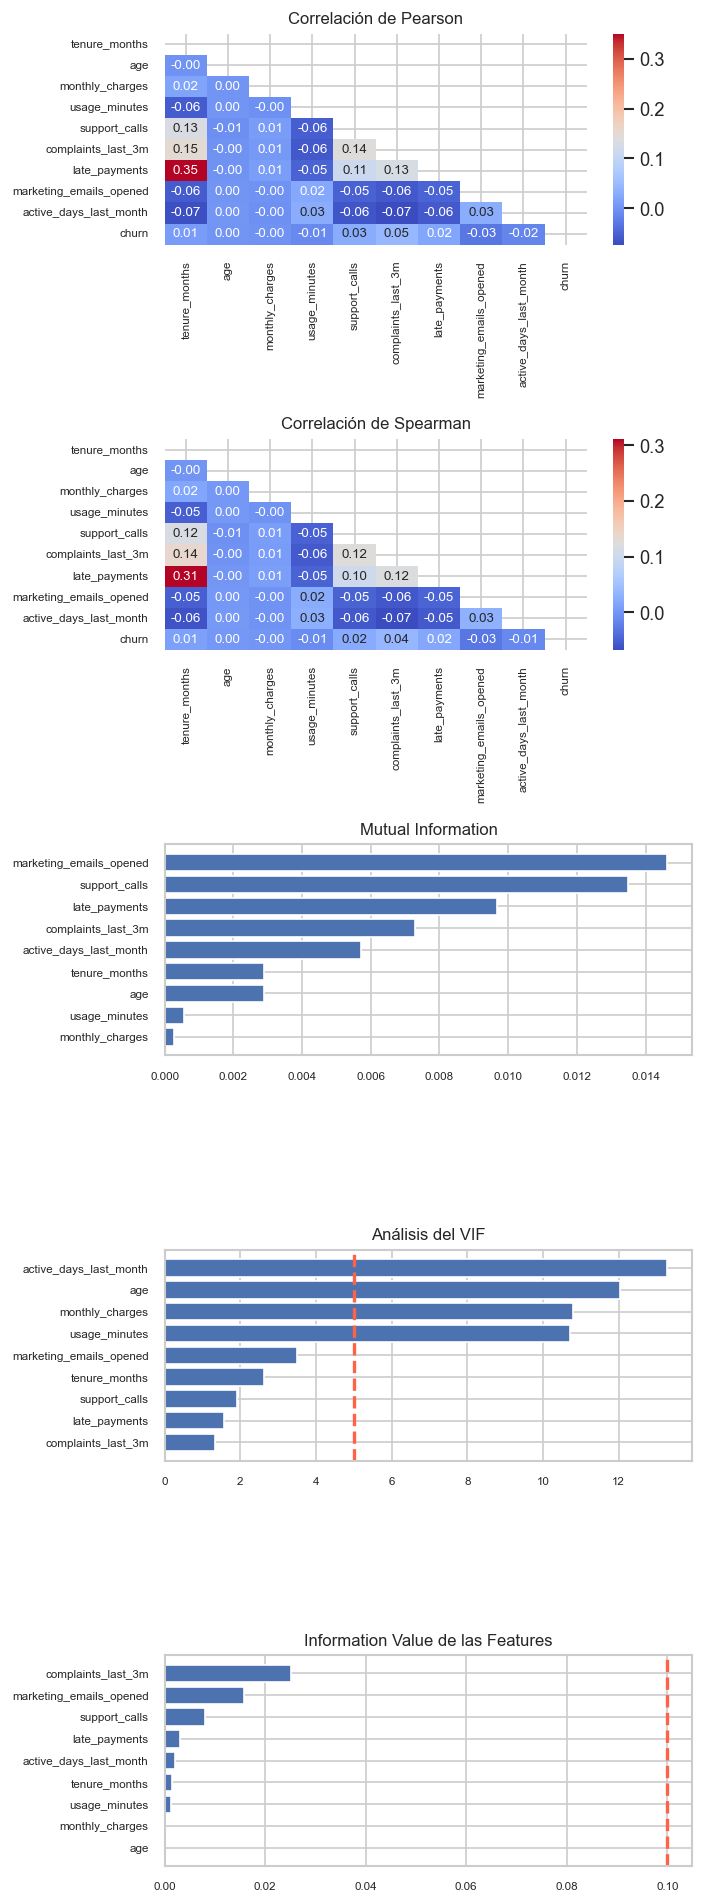

In [36]:
corr = df.corr('pearson', numeric_only= True)
mask = np.triu(
    np.ones_like(corr, dtype= bool)
)
fig, ax = plt.subplots(5, 1, figsize = (6, 16))
sns.heatmap(
    data= corr,
    mask= mask,
    ax= ax[0],
    annot= True,
    cmap= 'coolwarm',
    square= False,
    fmt = '.2f',
    annot_kws= {
        'fontsize': 8
    }
)
ax[0].set_title('Correlación de Pearson', fontsize = 10)
ax[0].tick_params(axis = 'x', labelsize = 7)
ax[0].tick_params(axis = 'y', labelsize = 7)

## Gráfico 2

corr_spearman = df.corr('spearman', numeric_only= True)
mask_spearman = np.triu(
    np.ones_like(corr_spearman, dtype= bool)
)

sns.heatmap(
    data= corr_spearman,
    mask= mask_spearman,
    cmap= 'coolwarm',
    annot = True,
    annot_kws= {
        'fontsize': 8
    },
    fmt= '.2f',
    ax= ax[1]
)
ax[1].set_title('Correlación de Spearman', fontsize = 10)
ax[1].tick_params(axis = 'x', labelsize = 7)
ax[1].tick_params(axis = 'y', labelsize = 7)

## Gráfico 3
ax[2].barh(
    mi_df['feature'][::-1],
    mi_df['mutual_info'][::-1]
)
ax[2].set_title('Mutual Information', fontsize = 10)
ax[2].tick_params(axis = 'x', labelsize = 7)
ax[2].tick_params(axis = 'y', labelsize = 7)

## Gráfico 4: VIF
ax[3].barh(
    vif_df['feature'][::-1],
    vif_df['VIF'][::-1]
)
ax[3].set_title('Análisis del VIF', fontsize = 10)
ax[3].tick_params(axis = 'x', labelsize = 7)
ax[3].tick_params(axis = 'y', labelsize = 7)
ax[3].axvline(
    x = 5,
    linestyle = '--',
    color = 'tomato',
    linewidth = 2
)

## Gráfico 5: IV
ax[4].barh(
    iv['Feature'][::-1],
    iv['Information Value'][::-1]
)
ax[4].set_title('Information Value de las Features', fontsize = 10)
ax[4].tick_params(axis = 'x', labelsize = 7)
ax[4].tick_params(axis = 'y', labelsize = 7)
ax[4].axvline(
    x = 0.1,
    color = 'tomato',
    linestyle = '--',
    linewidth = 2
)

plt.tight_layout()

fig.savefig(
    '../artifacts/eda/figures/analisis_de_correlaciones.png',
    dpi = 300,
    bbox_inches = 'tight',
    facecolor = 'white'
)

plt.show()

In [37]:
eda_relaciones = f'''=== Reporte de Análisis de Relaciones ===

Se evidencia con el análisis de Pearson que no encontramos una relación lineal 
entre las variables por pares ni contra el target.

Además, con Spearman vemos un comportamiento similar, puesto que no se encuentran indicios
de que exista una relación monotónica fuerte entre las features y el target.

Siguiendo con el análisis entre variables por pares, nos apoyamos utilizando Mutual Information
el cual también nos da indicios que no existen relaciones lineales o no lineales fuertes
entre algún feature y el target. Aunque si podemos mencionar que 'support_calls' es la variable
con mayor aporte de información vs las demás.

Ahora, mirando las relaciones multivariables lineales utilizamos el VIF, con el cual podemos 
interpretar de que existen 4 features con un VIF > 5, por lo que inferimos multicolinealidad
moderada en ellas. Se tomará en consideración para el feature engineering.

Por último, en la gráfica de Information Value podemos ver que ninguna feature por si sola logra
tener un poder predictivo débil, ya que están más cercanas a 0. Pero si es relevante mencionar
que la feature con mayor intuición de poder predictivo es 'support_calls'.
'''
print(eda_relaciones)

=== Reporte de Análisis de Relaciones ===

Se evidencia con el análisis de Pearson que no encontramos una relación lineal 
entre las variables por pares ni contra el target.

Además, con Spearman vemos un comportamiento similar, puesto que no se encuentran indicios
de que exista una relación monotónica fuerte entre las features y el target.

Siguiendo con el análisis entre variables por pares, nos apoyamos utilizando Mutual Information
el cual también nos da indicios que no existen relaciones lineales o no lineales fuertes
entre algún feature y el target. Aunque si podemos mencionar que 'support_calls' es la variable
con mayor aporte de información vs las demás.

Ahora, mirando las relaciones multivariables lineales utilizamos el VIF, con el cual podemos 
interpretar de que existen 4 features con un VIF > 5, por lo que inferimos multicolinealidad
moderada en ellas. Se tomará en consideración para el feature engineering.

Por último, en la gráfica de Information Value podemos ver que ni

In [38]:
reporte_eda = "\n".join(['## Reporte EDA - Churn Prediction',
                           eda_data_overview, 
                           eda_reporte_missing, 
                           eda_analisis_feats_numericas,
                           eda_analisis_feats_categoricas,
                           eda_analisis_target,
                           eda_relaciones])
with open('../reports/reporte_eda.md', 'w') as f:
    f.write(reporte_eda)

### Guardando en MLFLOW

In [39]:
dagshub.init(repo_owner='davidrodriguez2712', repo_name='proyecto-3-prediccion-churn', mlflow=True)


Accessing as davidrodriguez2712

Initialized MLflow to track repo "davidrodriguez2712/proyecto-3-prediccion-churn"

Repository davidrodriguez2712/proyecto-3-prediccion-churn initialized!

In [41]:
mlflow.set_tracking_uri('https://dagshub.com/davidrodriguez2712/proyecto-3-prediccion-churn.mlflow')
#mlflow.create_experiment(name= 'Proyecto-3-prediccion-churn')
mlflow.set_experiment('Proyecto-3-prediccion-churn')

<Experiment: artifact_location='mlflow-artifacts:/4eff3ac96700445fbbce571d47c1a5ac', creation_time=1781404772946, experiment_id='0', last_update_time=1781404772946, lifecycle_stage='active', name='Proyecto-3-prediccion-churn', tags={'mlflow.experimentKind': 'custom_model_development'}, trace_location=None, workspace='default'>

In [42]:
with mlflow.start_run(run_name='01_eda') as run:
    mlflow.log_artifacts(
        local_dir= '../artifacts/eda/figures',
        artifact_path= 'eda/figures'
    )
    mlflow.log_artifacts(
        local_dir= '../artifacts/eda/tables',
        artifact_path= 'eda/tables'
    )
    mlflow.log_artifact(
        local_path= '../reports/reporte_eda.md',
        artifact_path= 'eda/reports'
    )

🏃 View run 01_eda at: https://dagshub.com/davidrodriguez2712/proyecto-3-prediccion-churn.mlflow/#/experiments/0/runs/a924f2f0ec5749d78f86bf6018ad029f
🧪 View experiment at: https://dagshub.com/davidrodriguez2712/proyecto-3-prediccion-churn.mlflow/#/experiments/0
